<a href="https://colab.research.google.com/github/andrew-janes-07/cartpendulums-lqr-control/blob/main/notebooks/03_triple_pendulum_control.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Triple Pendulum on a Cart — LQR Stabilization with a Deadband

The triple pendulum exhibits many similar nonlinear and chaotic features as the double pendulum and is more difficult to control due to the extra link and the interactions between the new angle and the two that already existed.

The state space for the cart-triple pendulum system contains 8 coordinates, $[x_c, \theta_1, \theta_2, \theta_3, \dot{x}_c, \dot{\theta}_1, \dot{\theta}_2, \dot{\theta}_3]$, and this system has 7 unstable equilibriums corresponding to the choices of each angle $\theta_i$ equal to $0$ or $\pi$. The only fully stable equilibrium is the case where each angle is 0 corresponding to the fully hanging case.

This system is controllable but with a significantly smaller basin for successful control using LQR. This notebook will focus entirely on the cart-pendulums system, confirming energy conservation, analyzing the linear dynamics around the fully vertical case, performing Q and R analysis, exploring pure LQR for multiple stability points, and finally adding a deadband control.

# LQR control with a deadband for a cart-triple pendulum system.

In [41]:
# Setup
try:
    import google.colab  # noqa
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import os
    if not os.path.exists("cartpendulums-lqr-control"):
        !git clone https://github.com/andrew-janes-07/cartpendulums-lqr-control.git
    %cd cartpendulums-lqr-control
    #!pip install -q -r requirements.txt
else:
    import sys
    sys.path.append("..")

Cloning into 'cartpendulums-lqr-control'...
remote: Enumerating objects: 74, done.
remote: Counting objects: 100% (74/74), done.
remote: Compressing objects: 100% (65/65), done.
remote: Total 74 (delta 13), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (74/74), 2.61 MiB | 10.36 MiB/s, done.
Resolving deltas: 100% (13/13), done.
/content/cartpendulums-lqr-control/cartpendulums-lqr-control


In [42]:
import numpy as np
import matplotlib.pyplot as plt
from src.config import PendulumConfig
from src.system import PendulumSystem
from src.controllers import LQRController, DeadbandActuator

In [43]:
def plot_pendulum_states(sim, n: int, is_cart: bool, title_prefix: str = "", figsize=None, fig=None, axes=None, label=None, color=None):
    """
    Plot state trajectories for an n-link pendulum, with or without a cart.

    State vector layout:
        Cart:        [x, θ₁..θₙ, ẋ, ω₁..ωₙ]
        Fixed-pivot: [θ₁..θₙ, ω₁..ωₙ]

    Parameters
    ----------
    sim        : OdeResult from solve_ivp
    n          : number of pendulum links
    is_cart    : whether system has a cart
    title_prefix: optional string prepended to each subplot title
    figsize    : override default figure size
    """
    n_coords = n + int(is_cart)  # total generalised coordinates

    if figsize is None:
        figsize = (12, 6 * n_coords)

    if fig is None or axes is None:
        fig, axes = plt.subplots(n_coords, 2, figsize=figsize)
        if n_coords == 1:
            axes = axes[np.newaxis, :]
    # --- build label lists in state vector order ---
    if is_cart:
        coord_labels  = [r"$x_c$ (m)"]        + [rf"$\theta_{i+1}$ (rad)" for i in range(n)]
        vel_labels    = [r"$\dot{x}_c$ (m/s)"] + [rf"$\dot{{\theta}}_{i+1}$ (rad/s)" for i in range(n)]
        coord_titles  = [r"$x_c$"]             + [rf"$\theta_{i+1}$" for i in range(n)]
        vel_titles    = [r"$\dot{x}_c$"]       + [rf"$\dot{{\theta}}_{i+1}$" for i in range(n)]
    else:
        coord_labels  = [rf"$\theta_{i+1}$ (rad)"     for i in range(n)]
        vel_labels    = [rf"$\dot{{\theta}}_{i+1}$ (rad/s)" for i in range(n)]
        coord_titles  = [rf"$\theta_{i+1}$"            for i in range(n)]
        vel_titles    = [rf"$\dot{{\theta}}_{i+1}$"    for i in range(n)]

    prefix = f"{title_prefix} " if title_prefix else ""

    for i in range(n_coords):
        # positions/angles in first half of state vector, velocities in second half
        axes[i, 0].plot(sim.t, sim.y[i], label=label, color=color, linewidth=.5)
        axes[i, 1].plot(sim.t, sim.y[i + n_coords], label=label, color=color, linewidth=.5)

        axes[i, 0].set_xlabel("time (s)")
        axes[i, 1].set_xlabel("time (s)")
        axes[i, 0].set_ylabel(coord_labels[i])
        axes[i, 1].set_ylabel(vel_labels[i])
        axes[i, 0].set_title(f"{prefix}{coord_titles[i]} vs t")
        axes[i, 1].set_title(f"{prefix}{vel_titles[i]} vs t")

    #fig.tight_layout()
    return fig, axes

def plot_phase_portraits(sim, n: int, is_cart: bool, title_prefix: str = "",
                         figsize=None, fig=None, axes=None,
                         label=None, color=None, mark_equilibrium=None):
    """
    Plot phase portraits (coordinate vs velocity) for an n-link pendulum,
    with or without a cart.

    State vector layout:
        Cart:        [x, θ₁..θₙ, ẋ, ω₁..ωₙ]
        Fixed-pivot: [θ₁..θₙ, ω₁..ωₙ]

    Parameters
    ----------
    sim              : OdeResult from solve_ivp
    n                : number of pendulum links
    is_cart          : whether system has a cart
    title_prefix     : optional string prepended to each subplot title
    figsize          : override default figure size
    fig, axes        : pass existing fig/axes to overlay multiple trajectories
    label, color     : forwarded to plot calls
    mark_equilibrium : optional state vector; if given, plot the corresponding
                       (coord, velocity) point as a red 'x' on each subplot
    """
    n_coords = n + int(is_cart)

    if figsize is None:
        figsize = (6, 6 * n_coords)

    if fig is None or axes is None:
        fig, axes = plt.subplots(n_coords, 1, figsize=figsize)
        if n_coords == 1:
            axes = np.array([axes])  # ensure indexable for n=1 fixed-pivot

    # --- build label lists in state vector order ---
    if is_cart:
        coord_labels = [r"$x_c$ (m)"]         + [rf"$\theta_{i+1}$ (rad)"     for i in range(n)]
        vel_labels   = [r"$\dot{x}_c$ (m/s)"] + [rf"$\dot{{\theta}}_{i+1}$ (rad/s)" for i in range(n)]
        coord_syms   = [r"$x_c$"]             + [rf"$\theta_{i+1}$"           for i in range(n)]
        vel_syms     = [r"$\dot{x}_c$"]       + [rf"$\dot{{\theta}}_{i+1}$"   for i in range(n)]
    else:
        coord_labels = [rf"$\theta_{i+1}$ (rad)"     for i in range(n)]
        vel_labels   = [rf"$\dot{{\theta}}_{i+1}$ (rad/s)" for i in range(n)]
        coord_syms   = [rf"$\theta_{i+1}$"           for i in range(n)]
        vel_syms     = [rf"$\dot{{\theta}}_{i+1}$"   for i in range(n)]

    prefix = f"{title_prefix} " if title_prefix else ""

    for i in range(n_coords):
        axes[i].plot(sim.y[i], sim.y[i + n_coords], linewidth=.5, label=label, color=color)
        axes[i].set_xlabel(coord_labels[i])
        axes[i].set_ylabel(vel_labels[i])
        axes[i].set_title(f"{prefix}{coord_syms[i]} vs {vel_syms[i]}")

        if mark_equilibrium is not None:
            axes[i].plot(mark_equilibrium[i], mark_equilibrium[i + n_coords],
                         'rx', markersize=10, markeredgewidth=2, label='Equilibrium')

    return fig, axes

## Cart Triple Pendulum Dynamics

Near Vertical Initial Conditions

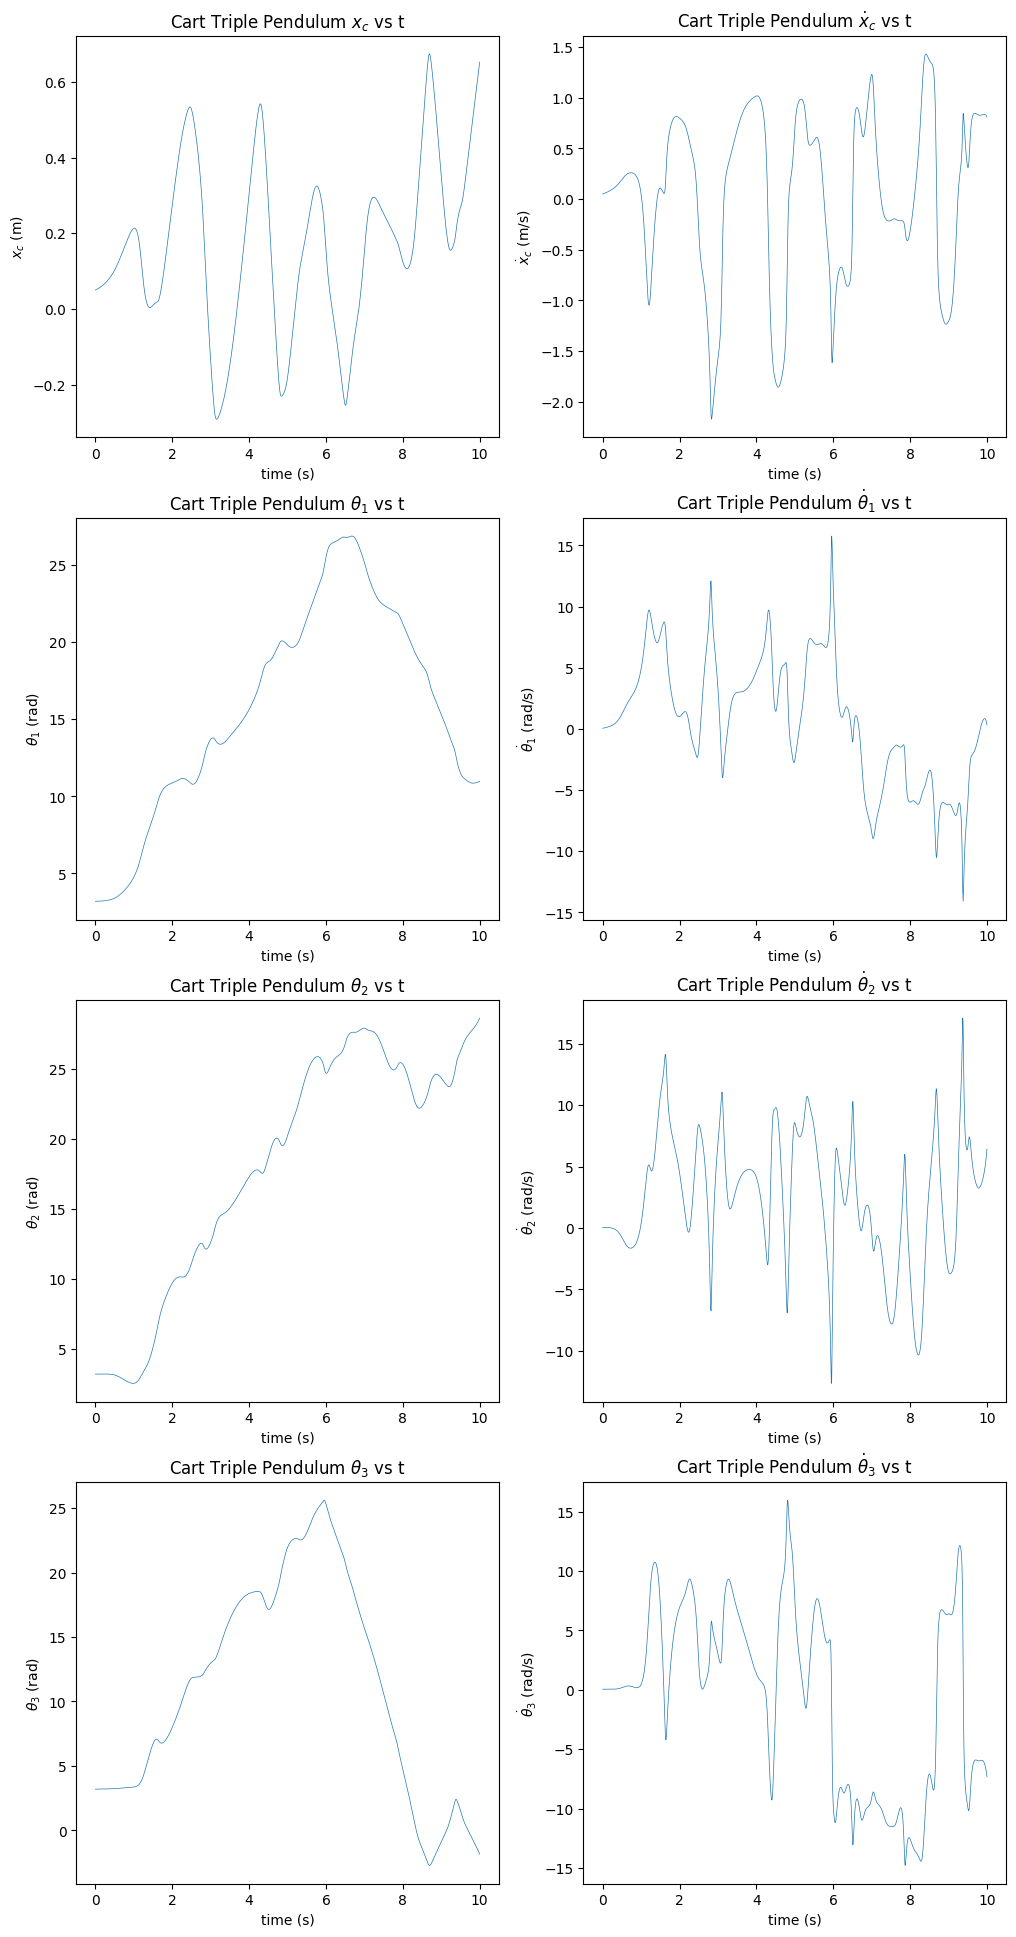

In [44]:
# Initialize Pendulum Configs class
n = 3
is_cart=True
params_triple = PendulumConfig.default_params(n=n, is_cart=is_cart) # Sets cart mass to 10kg, all pendulum masses to 1kg, and all lengths to 1m.
eps = .05
disturbance = np.array([0, eps, eps, eps, 0 , 0, 0])
near_vertical_ICs_triple = np.array([0, np.pi, np.pi, np.pi, 0, 0, 0, 0]) + eps # Sets initial conditions to the vertical with no intitial velocites with the disturbance added in.
sys_triple_cart_0 = PendulumSystem(n=n, is_cart=is_cart, cfg=params_triple, ICs=near_vertical_ICs_triple)

sim_triple_cart_0 = sys_triple_cart_0.simulate() # Uses defaults: solver='DOP853', t_span=(0,10), dt=.01, controller=None

# Plot coord vs time and velocity vs time
plot_pendulum_states(sim_triple_cart_0, n=n, is_cart=is_cart, title_prefix="Cart Triple Pendulum")
plt.show()

The plots show how quickly the state falls away from the unstable vertical equilibrium. This means the stabilization needs to be very strong at the release of the pendulums to catch the state effectively.

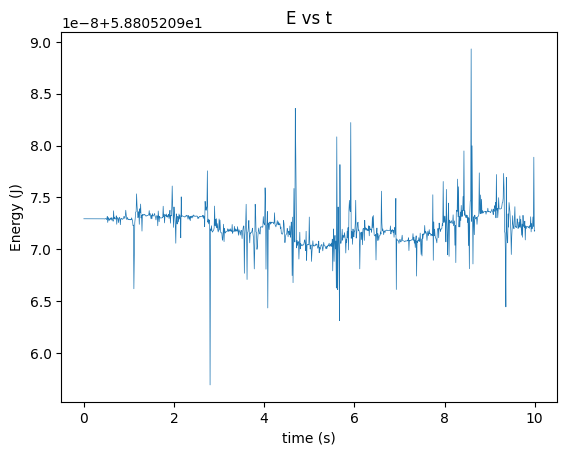

In [45]:
KE, PE, energy_triple_cart_0 = sys_triple_cart_0.energy_history()
plt.plot(sim_triple_cart_0.t, energy_triple_cart_0, linewidth=.5)
plt.xlabel('time (s)')
plt.ylabel('Energy (J)')
plt.title('E vs t')
plt.show()

The energy for the most complex system being explored is still conserved at the `1e-8` level which is acceptable error for such a nonlinear system.

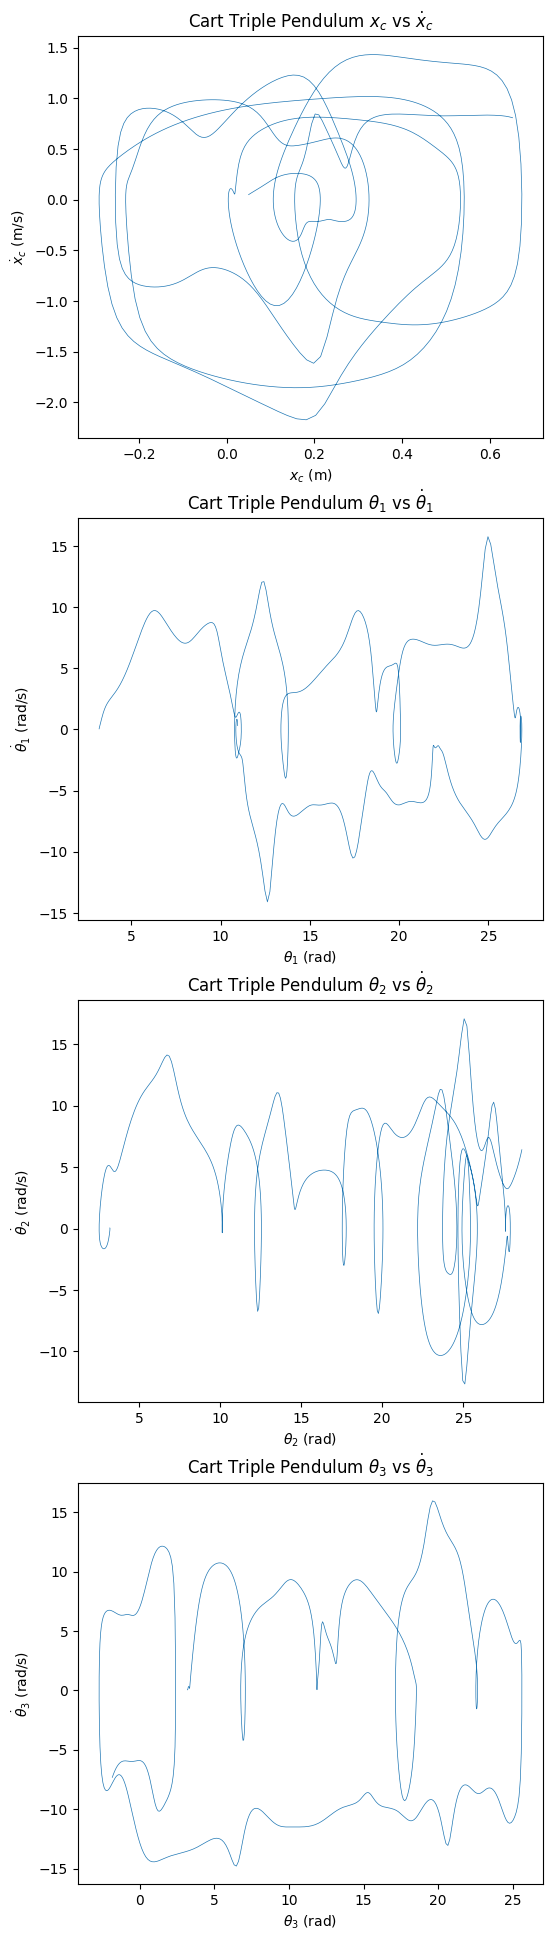

In [46]:
plot_phase_portraits(sim_triple_cart_0, n=n, is_cart=is_cart, title_prefix="Cart Triple Pendulum")
plt.show()

The phase portraits for the uncontrolled case show no pattern or convergence to any points which is to be expected.

## Linearization and LQR Design for the vertical case.

The linearization is being done numerically with a centered finite difference around the stability point. Since we are using the linear system to form LQR that controls an extremely nonlinear system, the linearized system needs to just be approximately correct in that close region.

By calculating the eigenvalues of the linear system $\dot{x} = Ax$, where $x$ is the full state vector, we can verify the linearization is producing a model that correctly models the local system.

In [47]:
# Calculate the A matrix for the 8-d linear system x_dot = Ax
y_eq = np.array([0, np.pi, np.pi, np.pi, 0, 0, 0, 0])
A, B = sys_triple_cart_0.linearize(y_eq, eps = 1e-10)
eigenvalues = np.linalg.eigvals(A)
print(eigenvalues)

[ 0.          0.         -7.92006516  7.92006516 -4.84900315 -2.23444488
  4.84900315  2.23444488]


The two zero eigenvalues correspond to the translation invariance of the cart-pendulum system and the three $\pm$ pairs correspond to the stable and unstable direction of each mode. There are 3 pairs corresponding to each unstable coordinate: each angle.

When we apply LQR, the new system $\dot{x} = Ax + Bu$ with the fact that $u = -Kx$ yields $\dot{x} = (A-BK)x$. Since the goal is to turn the unstable system into a stable one, calculating the eigenvalues of the new controlled system should give all negative or zero eigenvalues indicating the system is naturally attracted to the equilibrium.

In [48]:
# Compute K from the LQR control of the system for calculating A-BK
Q = np.diag([1, 10, 10, 10, 1, 1, 1, 1])
R = np.diag([.1])

LQRController = LQRController.design(system=sys_triple_cart_0, y_eq=y_eq, Q=Q, R=R)
K = LQRController.K
LQR_eigenvalues = np.linalg.eigvals(A-B@K)
print(LQR_eigenvalues)

[-8.02516272+0.j         -7.81422642+0.j         -4.95892574+0.j
 -4.74301842+0.j         -2.24449554+0.11331615j -2.24449554-0.11331615j
 -0.36896662+0.32298333j -0.36896662-0.32298333j]


In the LQR controlled linear system the eigenvalues all have negative real parts. This leads to convergence to the `y_eq` point.  

Open loop eigenvalues: $0,0, \pm 7.92, \pm 4.85, \pm 2.23$

Closed loop eigenvalues: $-8.03, -7.81, -4.96, -4.74, -2.24 \pm .11i, -.37 \pm .32i$

## LQR Control for Multiple Equilibrium Cases

### $(0, \pi, \pi, \pi)$ Equilibrium Case

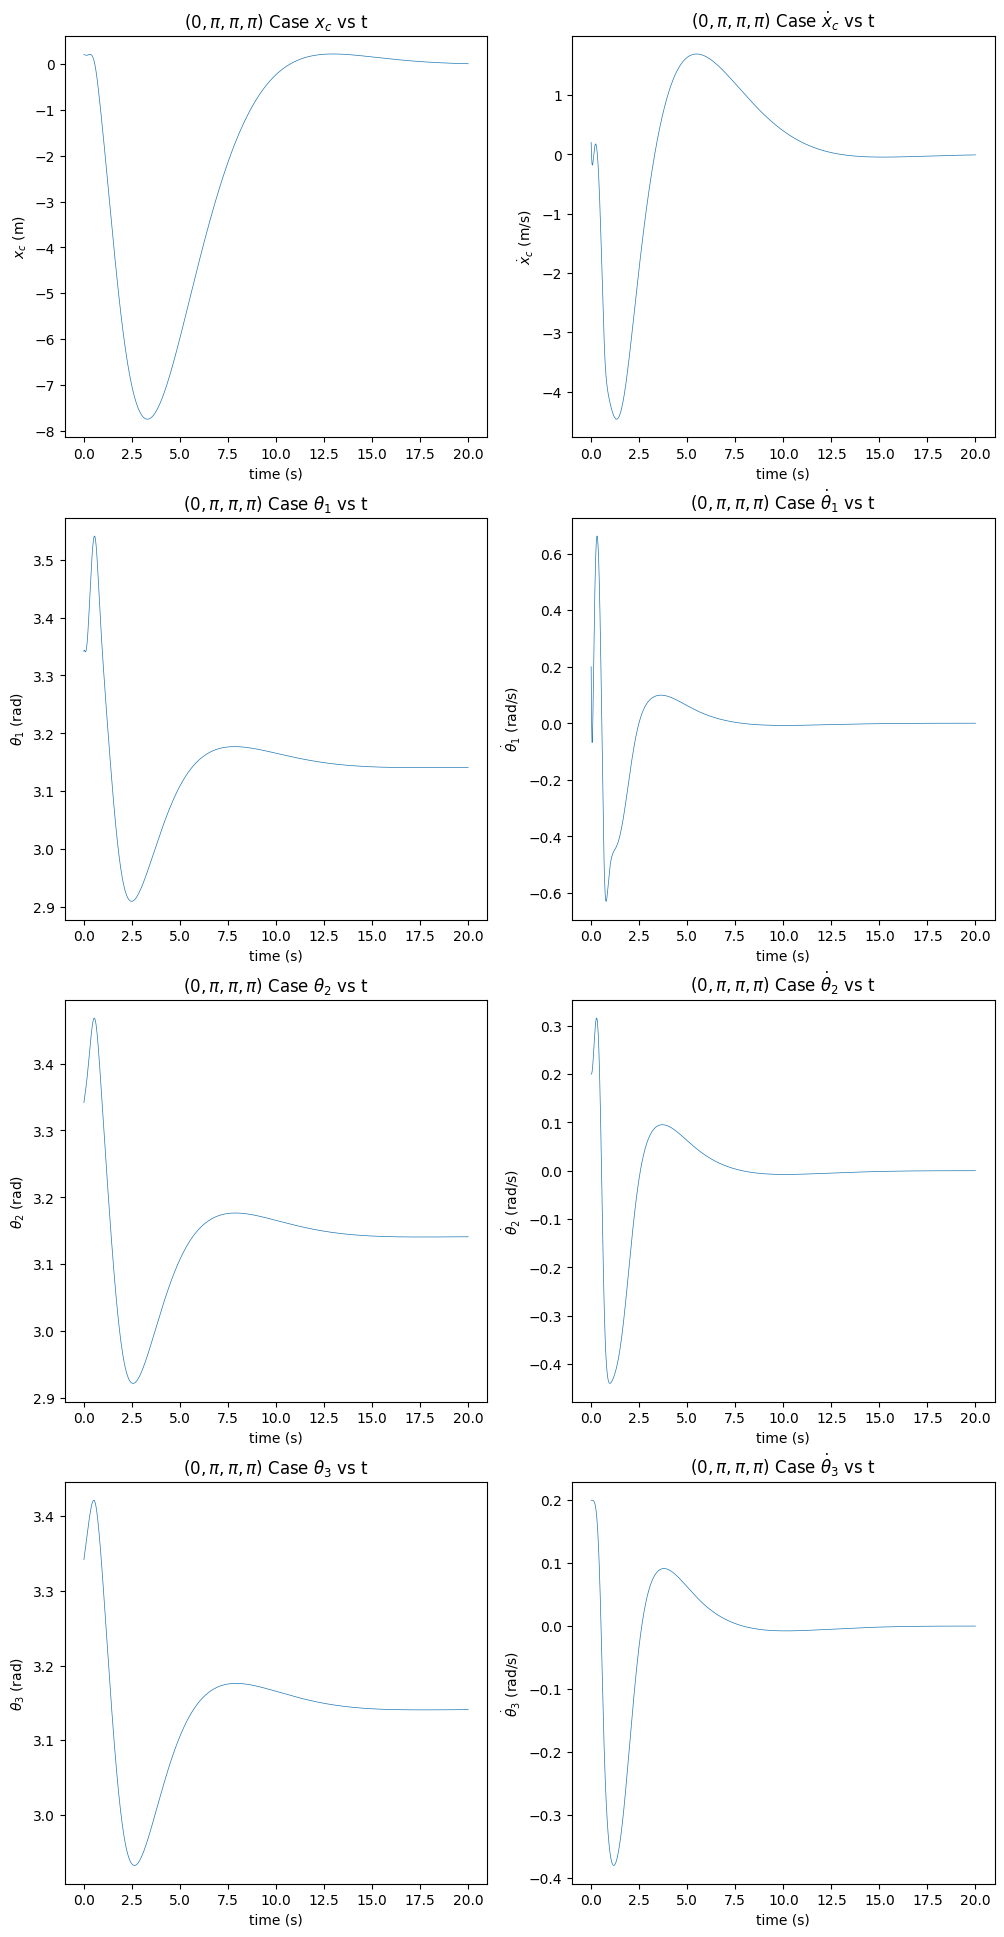

In [49]:
# Initialize Pendulum Configs class
n = 3
is_cart=True
params_triple = PendulumConfig.default_params(n=n, is_cart=is_cart) # Sets cart mass to 10kg, all pendulum masses to 1kg, and all lengths to 1m.
eps = .2
disturbance = np.array([0, eps, eps, eps, 0 , 0, 0])
near_vertical_ICs_triple = np.array([0, np.pi, np.pi, np.pi, 0, 0, 0, 0]) + eps # Sets initial conditions to the vertical with no intitial velocites with the disturbance added in.
sys_triple_cart_0 = PendulumSystem(n=n, is_cart=is_cart, cfg=params_triple, ICs=near_vertical_ICs_triple)

Q = np.diag([1, 10, 10, 10, 1, 1, 1, 1])
R = np.diag([.1])

LQRController = LQRController.design(system=sys_triple_cart_0, y_eq=y_eq, Q=Q, R=R)

sim_triple_cart_0 = sys_triple_cart_0.simulate(t_span=(0,20), controller=LQRController) # Uses defaults: solver='DOP853', t_span=(0,10), dt=.01, controller=None

# Plot coord vs time and velocity vs time
plot_pendulum_states(sim_triple_cart_0, n=n, is_cart=is_cart, title_prefix=r"$(0, \pi, \pi, \pi)$ Case")
plt.show()

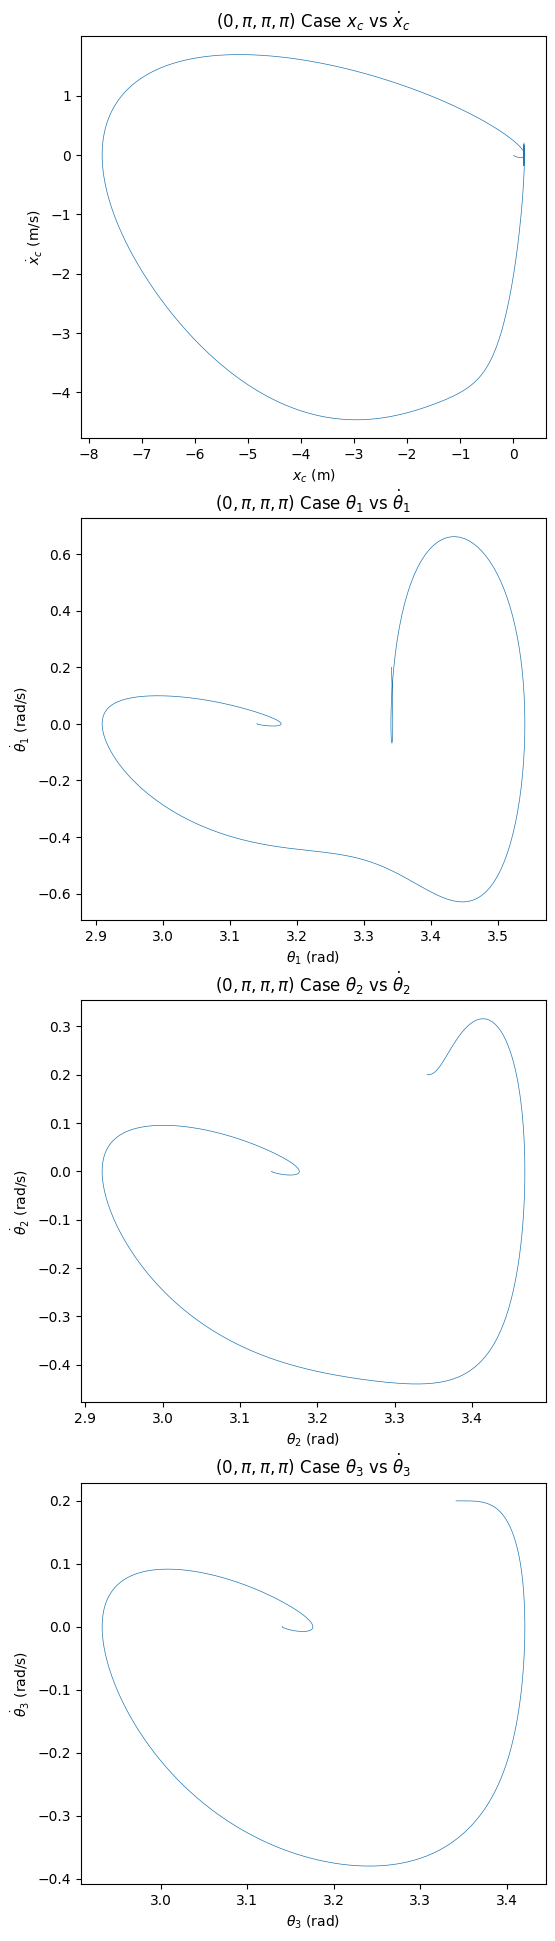

In [50]:
plot_phase_portraits(sim_triple_cart_0, n=n, is_cart=is_cart, title_prefix=r"$(0, \pi, \pi, \pi)$ Case")
plt.show()

Both the coordinate-time plots and the coordinate-velocity plots show the convergence to equilibirum well. The system is able to recover to stability within about 13 seconds.

### $(0, \pi, 0, \pi)$ Equilibrium Case

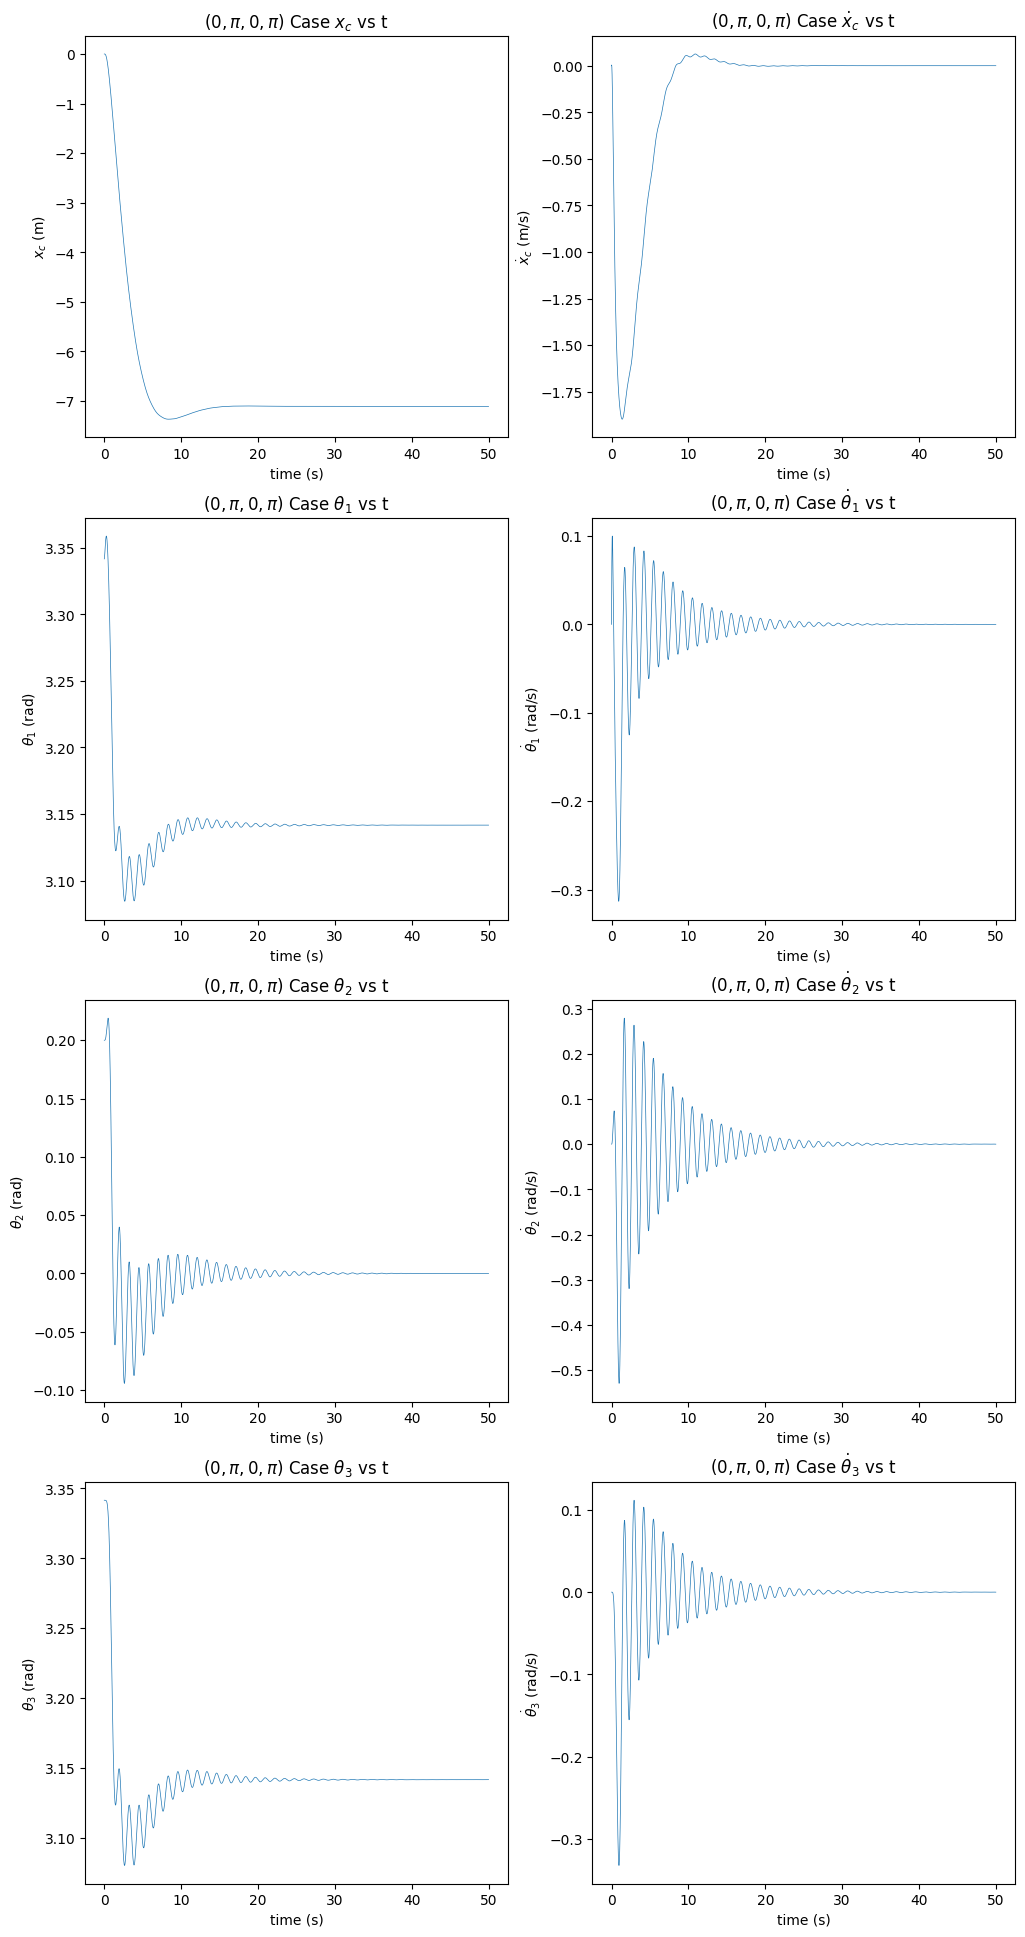

In [51]:
# Initialize Pendulum Configs class
n = 3
is_cart=True
params_triple = PendulumConfig.default_params(n=n, is_cart=is_cart) # Sets cart mass to 10kg, all pendulum masses to 1kg, and all lengths to 1m.
eps = 0.2
disturbance = np.array([0, eps, eps, eps, 0 , 0, 0, 0])
near_vertical_ICs_triple_1 = np.array([0, np.pi, 0, np.pi, 0, 0, 0, 0]) + disturbance # Sets initial conditions to the vertical with no intitial velocites with the disturbance added in.
sys_triple_cart_1 = PendulumSystem(n=n, is_cart=is_cart, cfg=params_triple, ICs=near_vertical_ICs_triple_1)

Q = np.diag([1, 10, 10, 10, 1, 1, 1, 1])
R = np.diag([.1])

LQRController = LQRController.design(system=sys_triple_cart_1, y_eq=near_vertical_ICs_triple_1, Q=Q, R=R)

sim_triple_cart_1 = sys_triple_cart_1.simulate(t_span=(0,50), controller=LQRController) # Uses defaults: solver='DOP853', t_span=(0,10), dt=.01, controller=None

# Plot coord vs time and velocity vs time
plot_pendulum_states(sim_triple_cart_1, n=n, is_cart=is_cart, title_prefix=r"$(0, \pi, 0, \pi)$ Case")
plt.show()

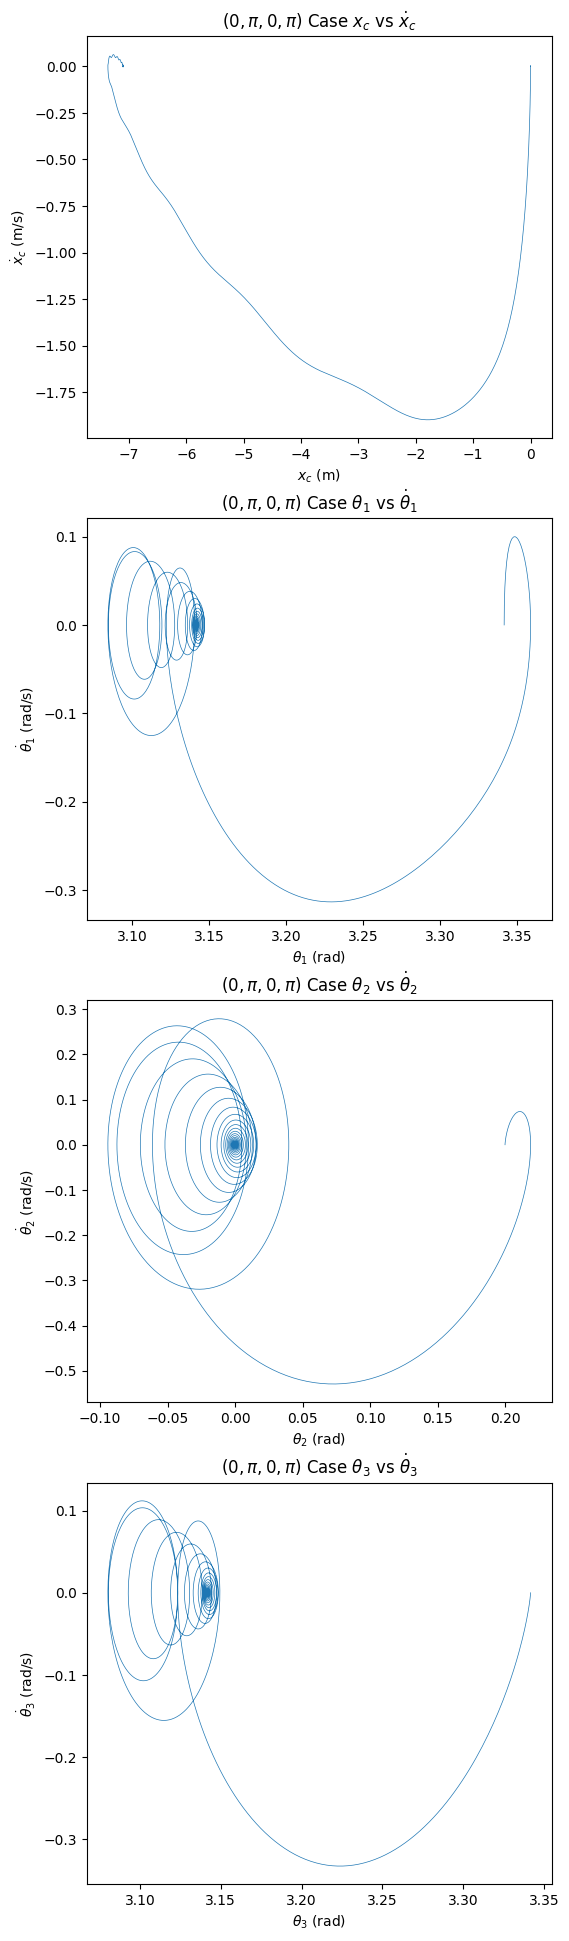

In [52]:
plot_phase_portraits(sim_triple_cart_1, n=n, is_cart=is_cart, title_prefix=r"$(0, \pi, 0, \pi)$ Case")
plt.show()

This equilibrium with two pendulums facing upward and one facing down perfectly demonstrates the different types of dynamics this system can generate. For the fully vertical case, the system quickly converges without significant oscillaiton. However, in this case, the system oscillates significantly with decay to the equilibrium.

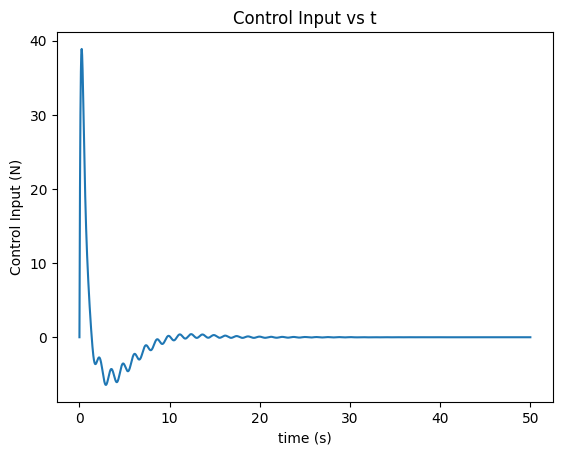

In [53]:
plt.plot(sim_triple_cart_1.t, sys_triple_cart_1.control_history)
plt.xlabel('time (s)')
plt.ylabel('Control Input (N)')
plt.title('Control Input vs t')
plt.show()

The force input for this system looks very similar with oscillation around zero decaying as the system reaches equilibrium.

## Adding Deadband to LQR Control for the Cart-Triple Pendulum system

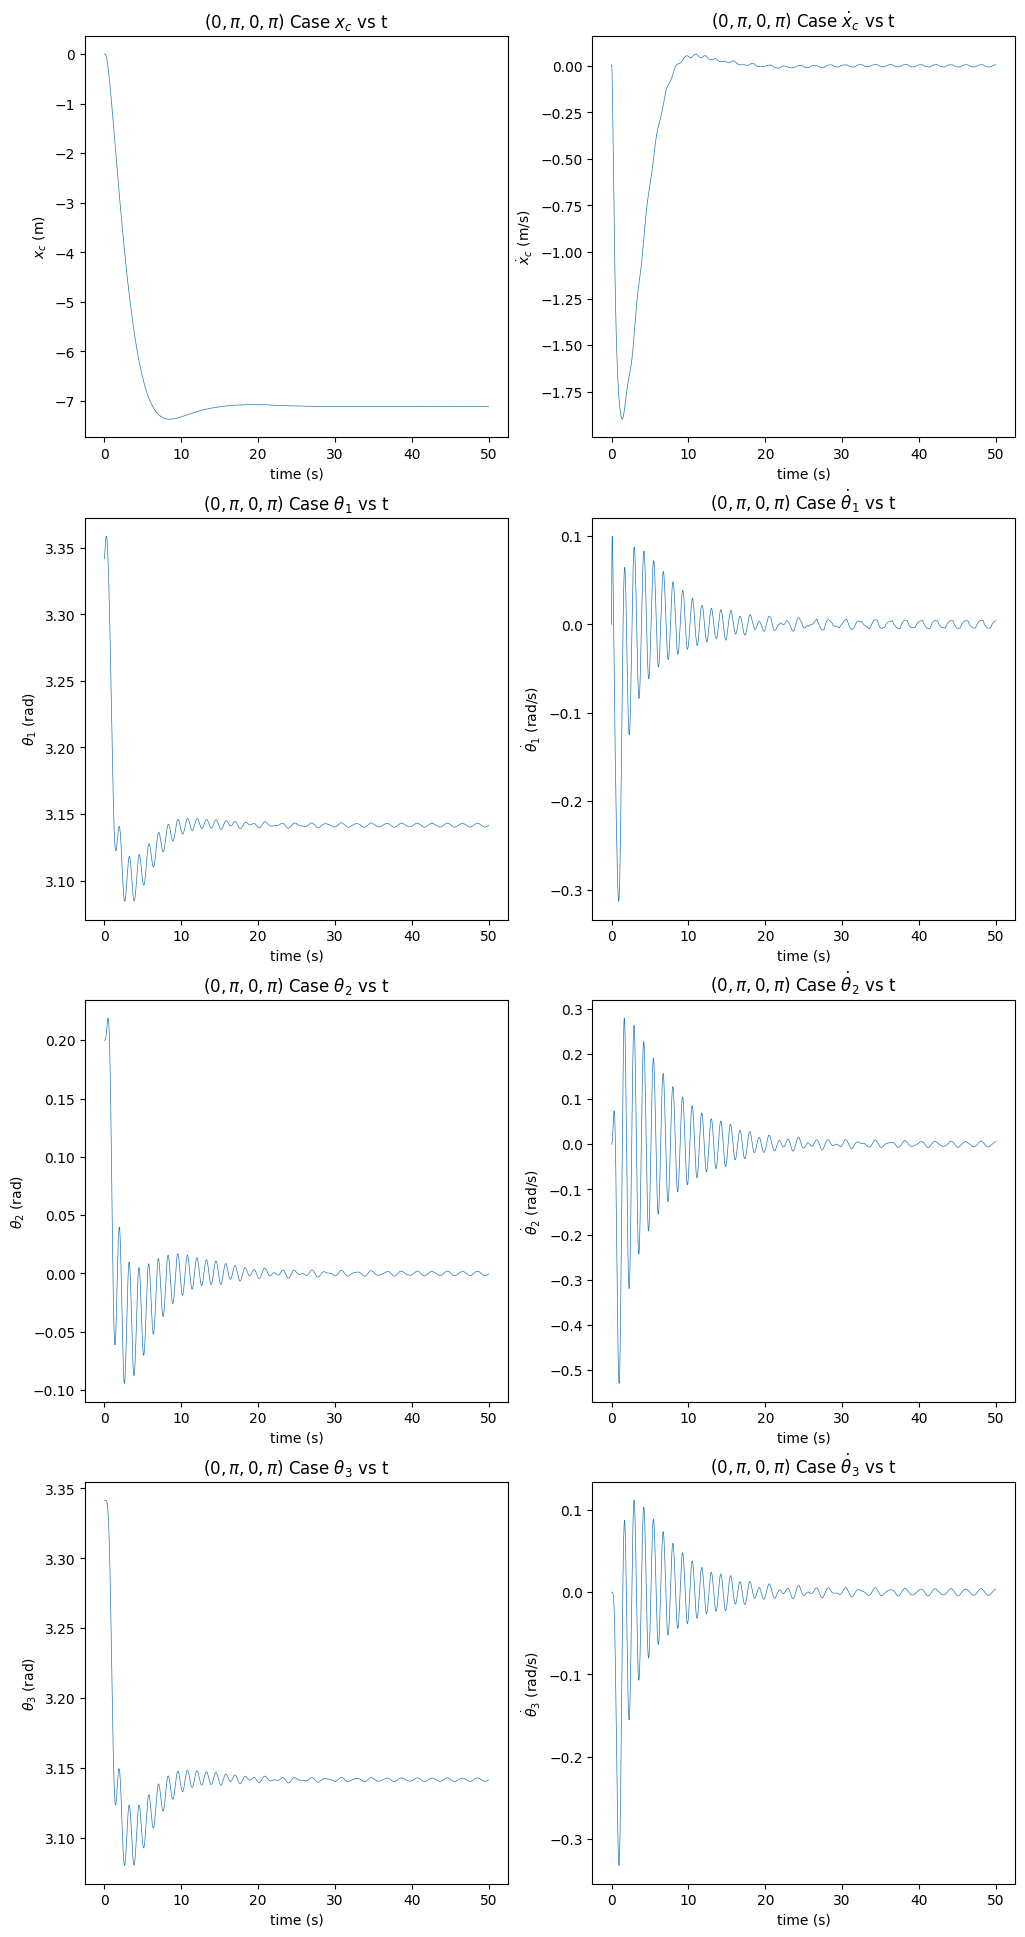

In [56]:
# Initialize Pendulum Configs class
n = 3
is_cart=True
params_triple = PendulumConfig.default_params(n=n, is_cart=is_cart) # Sets cart mass to 10kg, all pendulum masses to 1kg, and all lengths to 1m.
eps = 0.2
disturbance = np.array([0, eps, eps, eps, 0 , 0, 0, 0])
near_vertical_ICs_triple_2 = np.array([0, np.pi, 0, np.pi, 0, 0, 0, 0]) + disturbance # Sets initial conditions to the vertical with no intitial velocites with the disturbance added in.
sys_triple_cart_2 = PendulumSystem(n=n, is_cart=is_cart, cfg=params_triple, ICs=near_vertical_ICs_triple_2)

Q = np.diag([1, 10, 10, 10, 1, 1, 1, 1])
R = np.diag([.1])

LQR_Controller = LQRController.design(system=sys_triple_cart_2, y_eq=near_vertical_ICs_triple_1, Q=Q, R=R)
Deadband_Actuator = DeadbandActuator(LQR_Controller, deadband_on =.5, deadband_off=.25)

sim_triple_cart_2 = sys_triple_cart_2.simulate(t_span=(0,50), controller=Deadband_Actuator) # Uses defaults: solver='DOP853', t_span=(0,10), dt=.01, controller=None

# Plot coord vs time and velocity vs time
plot_pendulum_states(sim_triple_cart_2, n=n, is_cart=is_cart, title_prefix=r"$(0, \pi, 0, \pi)$ Case")
plt.show()

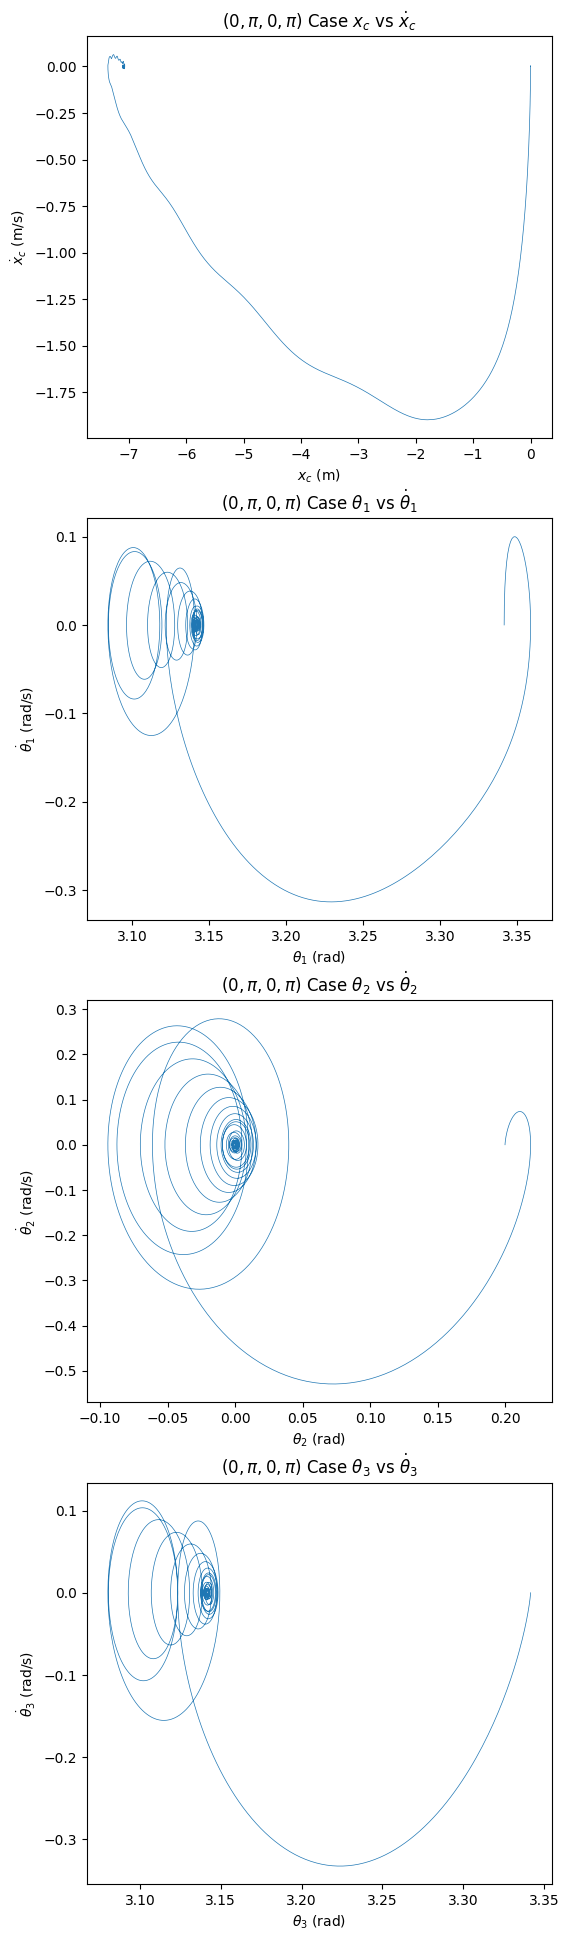

In [57]:
plot_phase_portraits(sim_triple_cart_2, n=n, is_cart=is_cart, title_prefix=r"$(0, \pi, 0, \pi)$ Case")
plt.show()

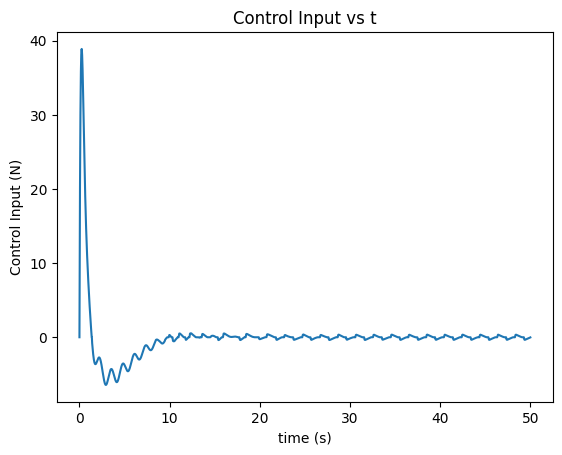

In [58]:
plt.plot(sim_triple_cart_2.t, sys_triple_cart_2.control_history)
plt.xlabel('time (s)')
plt.ylabel('Control Input (N)')
plt.title('Control Input vs t')
plt.show()

With the deadband added into the simulation, we still see similar oscillations for the mixed equilibrium case, but these oscillations are no longer as sinusoidal. They are more jagged and inconsistent as the controller no longer has such high precision and can only produce a force when the threshold is met.

# Conclusion
The triple pendulum on a cart is the natural endpoint of the LQR arc: an eight-dimensional,
underactuated, highly nonlinear system stabilized at an unstable equilibrium using only a
horizontal force on the cart. The same `PendulumSystem` architecture that handled the single
and double pendulum cases generalized without modification — the inertia matrix, linearization,
and LQR pipeline all scaled directly from $n=1$ to $n=3$.

Comparing the three systems makes the cost of complexity concrete. The single pendulum recovers
from initial angles up to roughly $\pi/2 - 0.38 \approx 1.19$ rad off vertical; the double
pendulum's region of attraction shrinks substantially; and the triple pendulum tolerates only
small perturbations from the fully upright state before the linear approximation breaks down
and control fails. The closed-loop spectrum tells the same story: increasingly stiff, with
fast pendulum modes alongside a much slower cart-position mode that dominates settling time.

LQR is the right tool for stabilization near an equilibrium, but it has clear limits. It cannot
swing up from the downward equilibrium, its guarantees vanish outside the linearized region,
and tuning $Q$ and $R$ becomes increasingly delicate as the state dimension grows. The deadband
results across all three notebooks illustrate the same physical reality: real actuators do not
produce the clean convergence that ideal LQR predicts, and the resulting steady-state
oscillation amplitude grows with system complexity.

Future aspects of this project include adding Kalman filtering and utilizing MPC for control. Longer term goals include using reinforcement learning to develop a swing up model that then stabilizes around specific equilibriums.